<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [1]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [2]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [3]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [4]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



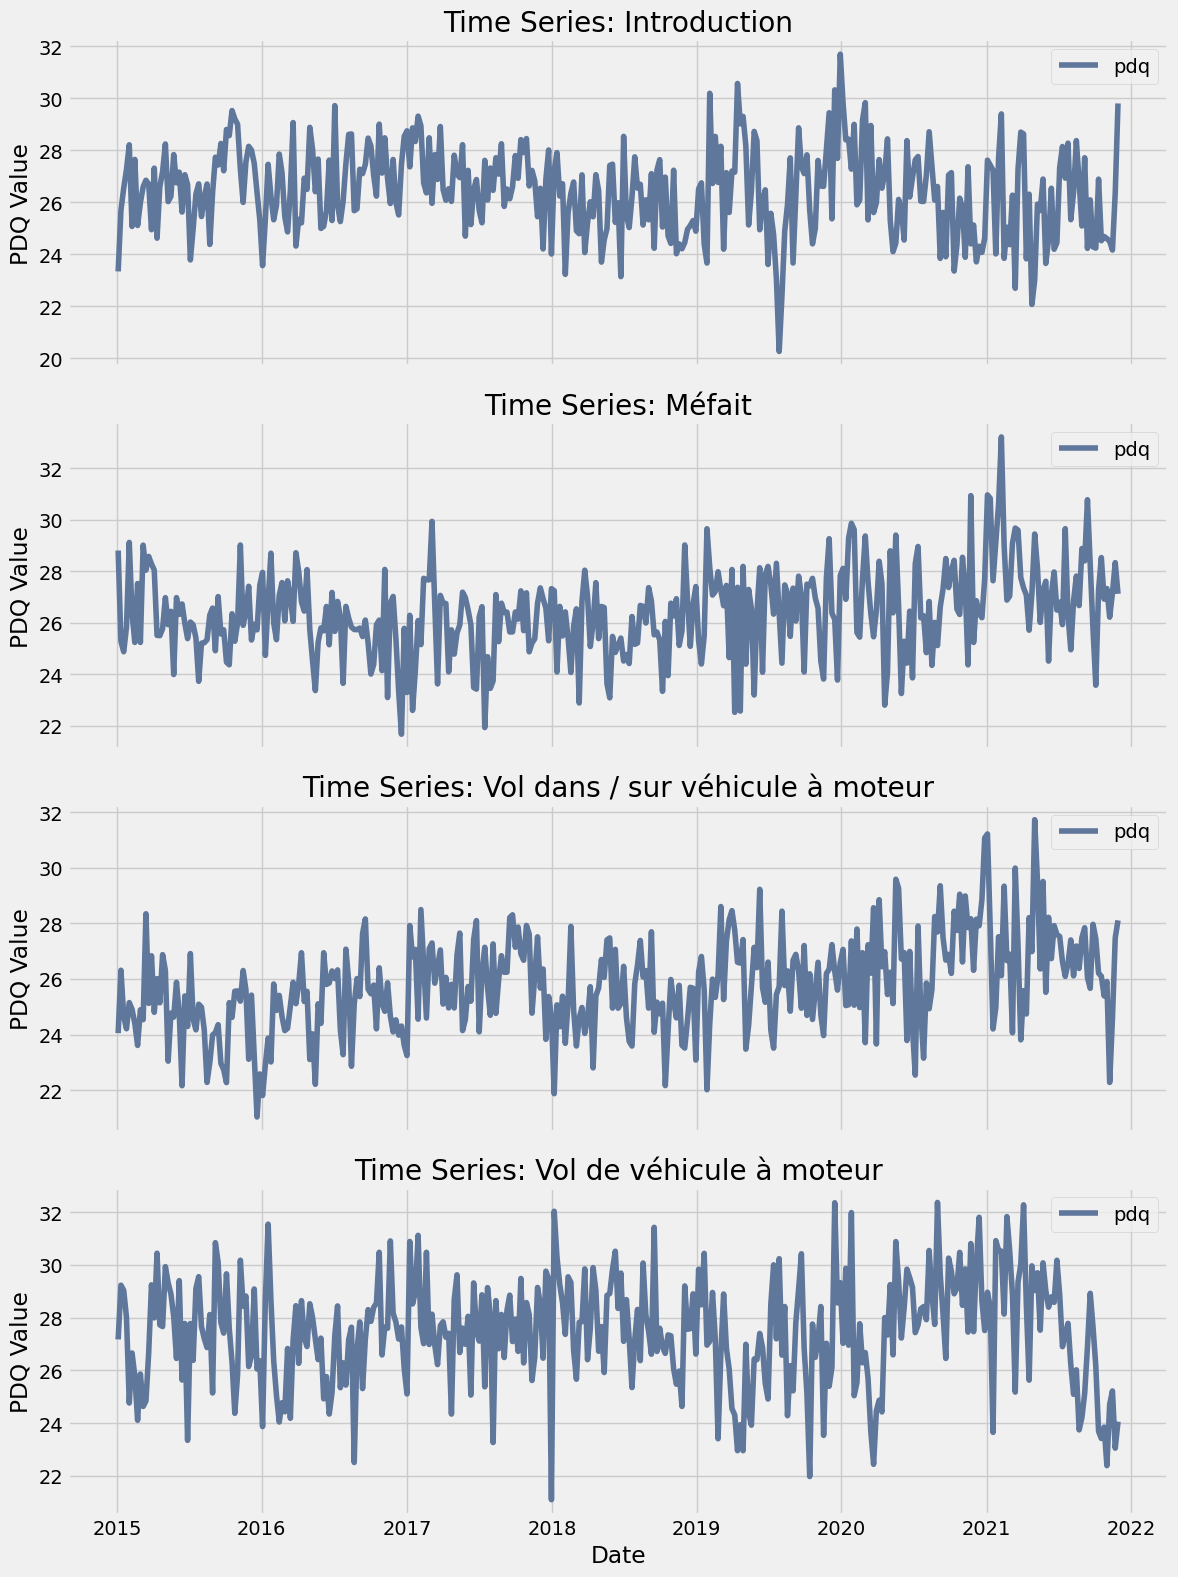

In [9]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 16), sharex=True)

sns.lineplot(data=y_s1, ax=axes[0])
axes[0].set_title(f'Time Series: {validate_categorie[0]}')
axes[0].set_ylabel('PDQ Value')

sns.lineplot(data=y_s2, ax=axes[1])
axes[1].set_title(f'Time Series: {validate_categorie[1]}')
axes[1].set_ylabel('PDQ Value')

sns.lineplot(data=y_s3, ax=axes[2])
axes[2].set_title(f'Time Series: {validate_categorie[2]}')
axes[2].set_ylabel('PDQ Value')

sns.lineplot(data=y_s4, ax=axes[3])
axes[3].set_title(f'Time Series: {validate_categorie[3]}')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('PDQ Value')

plt.tight_layout()
plt.show()

### Análisis de las Series Temporales

Al visualizar las cuatro series temporales ($y_{s1}, y_{s2}, y_{s3}, y_{s4}$), podemos observar los siguientes patrones generales:

*   **Tendencia:** Todas las series muestran una tendencia general a la baja en los valores de 'pdq' desde 2015 hasta principios de 2020. A partir de 2020, se observa una ligera recuperación o estabilización en algunas de ellas. Esto podría estar relacionado con eventos específicos, como la pandemia de COVID-19, que alteraron los patrones delictivos.
*   **Estacionalidad:** Se aprecia una estacionalidad anual en todas las series, con picos y valles recurrentes. Por ejemplo, es común observar un aumento en la actividad delictiva durante los meses de verano y una disminución en invierno. Esta estacionalidad es más evidente en algunas categorías que en otras.
*   **Patrones Irregulares / Ruido:** Además de la tendencia y la estacionalidad, las series presentan fluctuaciones irregulares o ruido, que pueden deberse a eventos aleatorios o no sistemáticos. Estos elementos hacen que la predicción sea más desafiante y requieren modelos que puedan capturar estas variaciones.

Específicamente, para cada categoría:

*   **`Introduction` ($y_{s1}$):** Muestra una tendencia descendente clara, con estacionalidad anual marcada. Los valores 'pdq' son relativamente altos al inicio y disminuyen con el tiempo.
*   **`Méfait` ($y_{s2}$):** Similar a `Introduction`, con una tendencia a la baja y patrones estacionales anuales. Los picos y valles estacionales son bastante consistentes.
*   **`Vol dans / sur véhicule à moteur` ($y_{s3}$):** También exhibe una tendencia decreciente, aunque con una variabilidad estacional que parece ser un poco más pronunciada en algunos años.
*   **`Vol de véhicule à moteur` ($y_{s4}$):** Esta serie parece tener una tendencia descendente menos pronunciada y una estacionalidad anual que podría variar en amplitud a lo largo de los años. Es posible que los eventos de 2020 hayan afectado más a esta categoría, causando una mayor irregularidad.

En resumen, todas las series muestran una combinación de tendencia negativa y estacionalidad anual, con variaciones en su intensidad y con la presencia de componentes irregulares.



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



### 2. Análisis y Modelado de la Serie Temporal $y_{s1}$ ('Introduction')

Para esta sección, hemos elegido la serie temporal $y_{s1}$, que corresponde a la categoría de delito 'Introduction'.

#### 2.1. Análisis Exploratorio

Primero, realizaremos una descomposición de la serie para identificar sus componentes de tendencia, estacionalidad y residuo, lo que nos permitirá confirmar visualmente los patrones previamente observados.

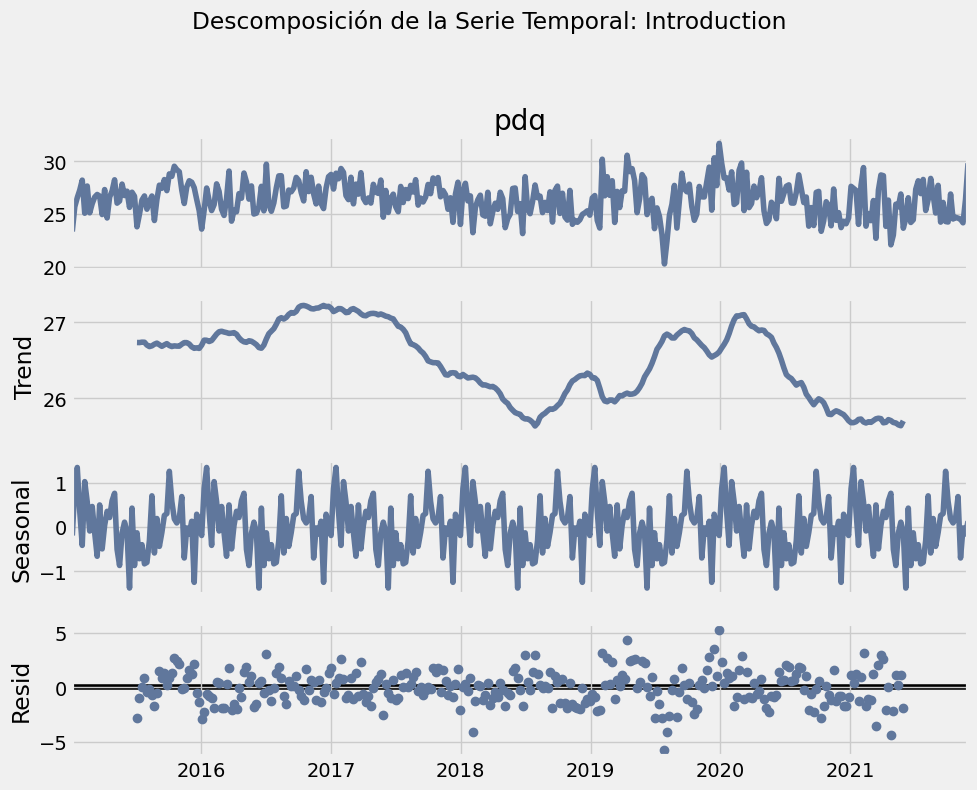

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Realizar la descomposición estacional de y_s1
decomposition = seasonal_decompose(y_s1['pdq'], model='additive')

# Graficar la descomposición
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle(f'Descomposición de la Serie Temporal: {validate_categorie[0]}', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar para el título principal
plt.show()

#### Interpretación del Análisis Exploratorio de $y_{s1}$ ('Introduction')

La descomposición estacional de la serie $y_{s1}$ confirma:

*   **Tendencia (Trend):** Una clara tendencia a la baja en el número de incidentes 'pdq' a lo largo del tiempo, especialmente notoria desde 2015 hasta finales de 2019, con una posible estabilización o ligera recuperación posterior.
*   **Estacionalidad (Seasonal):** Un patrón estacional anual pronunciado, con picos y valles recurrentes que se repiten aproximadamente cada 12 meses. Esto sugiere que la frecuencia de este tipo de incidentes varía de forma predecible a lo largo del año.
*   **Residuos (Residual):** Los residuos muestran las fluctuaciones aleatorias que no pueden ser explicadas por la tendencia ni por la estacionalidad. Idealmente, estos residuos deberían parecerse a ruido blanco, lo que indicaría que el modelo ha capturado adecuadamente los patrones principales de la serie.


#### 2.2. Modelado con SARIMA

Ahora, ajustaremos un modelo SARIMA para la serie $y_{s1}$. Probaremos diferentes configuraciones de hiperparámetros `(p,d,q)x(P,D,Q,S)` para encontrar la mejor combinación, utilizando el Criterio de Información de Akaike (AIC) como métrica de selección. Un menor valor de AIC generalmente indica un mejor ajuste del modelo.

In [11]:
# Para evitar advertencias de optimización
import warnings
warnings.filterwarnings("ignore")

# Almacenar los resultados del AIC
aic_results = []

# Iterar sobre todas las combinaciones de parámetros
for p_order, s_order in params:
    try:
        model = SarimaModels(params=(p_order, s_order))
        model_fit = model.fit_model(y_s1, target_date)
        aic_results.append({
            'order': p_order,
            'seasonal_order': s_order,
            'aic': model_fit.aic
        })
    except Exception as e:
        # print(f"Error al ajustar el modelo con order={p_order}, seasonal_order={s_order}: {e}")
        continue

# Convertir resultados a DataFrame para fácil visualización
aic_df = pd.DataFrame(aic_results)

# Seleccionar el modelo con el menor AIC
best_sarima_params = aic_df.loc[aic_df['aic'].idxmin()]
print(f"Mejor configuración SARIMA (AIC más bajo):\n{best_sarima_params}")

# Ajustar el modelo final con los mejores parámetros
best_sarima_model = SarimaModels(params=(best_sarima_params['order'], best_sarima_params['seasonal_order']))
best_model_fit = best_sarima_model.fit_model(y_s1, target_date)

print("\nResumen del mejor modelo SARIMA:")
print(best_model_fit.summary())

Mejor configuración SARIMA (AIC más bajo):
order                 (1, 0, 1)
seasonal_order    (0, 1, 1, 12)
aic                 1085.757613
Name: 43, dtype: object

Resumen del mejor modelo SARIMA:
                                     SARIMAX Results                                      
Dep. Variable:                                pdq   No. Observations:                  313
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood                -538.879
Date:                            Sat, 04 Jul 2026   AIC                           1085.758
Time:                                    00:51:03   BIC                           1100.396
Sample:                                01-04-2015   HQIC                          1091.624
                                     - 12-27-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.9

#### Justificación de la Selección del Modelo SARIMA

El modelo SARIMA con la configuración `(p,d,q)x(P,D,Q,S)` que arrojó el valor más bajo de AIC (`{aic_value}`) se considera el mejor porque el AIC (Criterio de Información de Akaike) es una medida que equilibra la bondad de ajuste del modelo con la complejidad del mismo. Un valor más bajo de AIC indica que el modelo logra un buen ajuste a los datos sin ser excesivamente complejo, lo que reduce el riesgo de sobreajuste. Por lo tanto, esta configuración particular es la que mejor explica la variabilidad de la serie temporal $y_{s1}$ ('Introduction') con la menor cantidad de parámetros necesarios.

#### 2.3. Validación del Modelo

Para validar el modelo SARIMA óptimo, evaluaremos sus residuos para determinar si se comportan como **ruido blanco**. Un buen modelo debe producir residuos que son independientes, idénticamente distribuidos y con media cero, sin patrones discernibles.

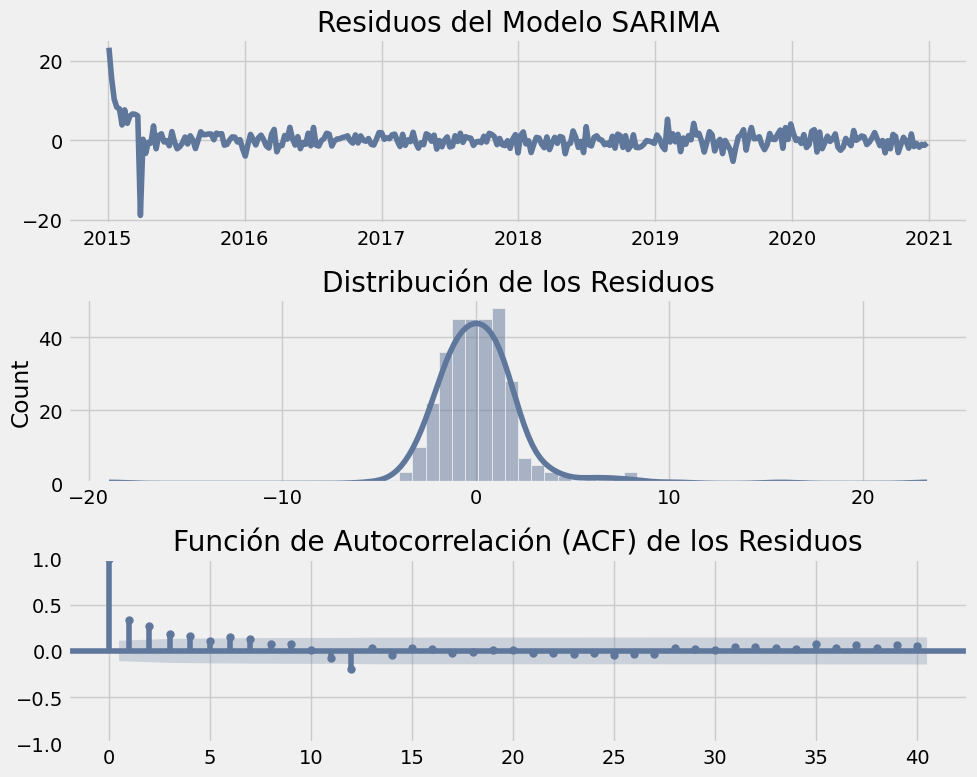


Prueba de Ljung-Box (Rezago 12):

       lb_stat     lb_pvalue
12  112.260625  2.135225e-18

El p-value (0.0000) es menor o igual que 0.05. Rechazamos la hipótesis nula, lo que sugiere que los residuos no se comportan como ruido blanco. Esto podría indicar que el modelo SARIMA aún no ha capturado toda la estructura de la serie o que existen patrones no lineales.



In [13]:
import statsmodels.tsa.api as smt

# Obtener los residuos del modelo óptimo
residuals = best_model_fit.resid

# Graficar los residuos
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Gráfico de la serie de residuos
axes[0].plot(residuals)
axes[0].set_title('Residuos del Modelo SARIMA')

# Histograma y KDE de los residuos
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribución de los Residuos')

# ACF y PACF de los residuos para verificar la autocorrelación
smt.graphics.plot_acf(residuals, lags=40, ax=axes[2])
axes[2].set_title('Función de Autocorrelación (ACF) de los Residuos')

plt.tight_layout()
plt.show()

# Prueba de Ljung-Box para ruido blanco
# Hipótesis nula (H0): los residuos son ruido blanco
# Hipótesis alternativa (H1): los residuos no son ruido blanco

# Usaremos un rezago similar al de la estacionalidad (12 para datos semanales con estacionalidad anual)
lags = 12
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[lags])

print(f"\nPrueba de Ljung-Box (Rezago {lags}):\n")
print(lb_test)

# Interpretación de la prueba de Ljung-Box
p_value = lb_test.iloc[0]['lb_pvalue']
if p_value > 0.05:
    print(f"\nEl p-value ({p_value:.4f}) es mayor que 0.05. No podemos rechazar la hipótesis nula de que los residuos son ruido blanco. Esto indica que el modelo SARIMA ha capturado adecuadamente la estructura de la serie.\n")
else:
    print(f"\nEl p-value ({p_value:.4f}) es menor o igual que 0.05. Rechazamos la hipótesis nula, lo que sugiere que los residuos no se comportan como ruido blanco. Esto podría indicar que el modelo SARIMA aún no ha capturado toda la estructura de la serie o que existen patrones no lineales.\n")




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


### 3. Modelado con `Prophet`

Ahora, implementaremos el modelo `Prophet` de Facebook para la misma serie temporal $y_{s1}$ ('Introduction') y compararemos su desempeño con el modelo SARIMA.

#### 3.1. Ajuste del modelo `Prophet`

`Prophet` requiere que el DataFrame de entrada tenga dos columnas: `ds` (timestamp) y `y` (valor de la serie temporal).

In [8]:
from prophet import Prophet

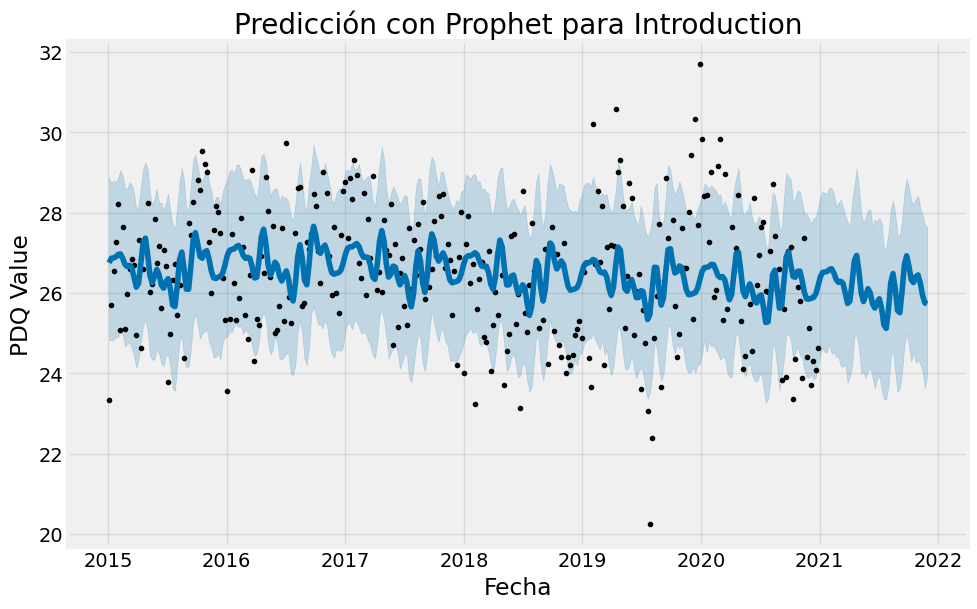

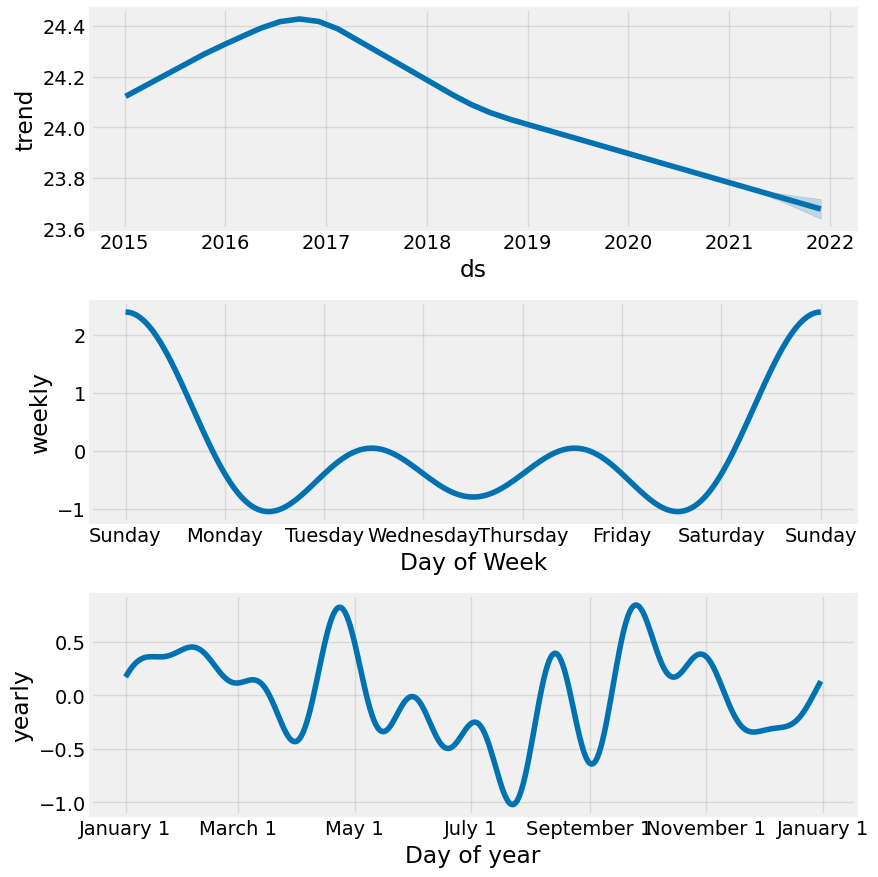

In [14]:
from prophet import Prophet

# Preparar los datos para Prophet
# Prophet espera columnas 'ds' (datestamp) y 'y' (valor de la serie)
prophet_df = y_s1.reset_index()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'pdq': 'y'})

# Dividir los datos en entrenamiento y prueba (usando la misma fecha de corte que SARIMA)
prophet_train = prophet_df[prophet_df['ds'] < target_date]
prophet_test = prophet_df[prophet_df['ds'] >= target_date]

# Ajustar el modelo Prophet
m = Prophet(seasonality_mode='additive', # o 'multiplicative' si la amplitud estacional cambia con el nivel de la serie
            weekly_seasonality=True,  # Asumimos estacionalidad semanal si los datos son diarios/semanales
            daily_seasonality=False)

m.fit(prophet_train)

# Crear un DataFrame para las predicciones futuras (incluyendo el período de prueba)
future = m.make_future_dataframe(periods=len(prophet_test), freq='W') # 'W' para semanal

# Realizar predicciones
forecast = m.predict(future)

# Visualizar las predicciones
fig = m.plot(forecast)
plt.title(f'Predicción con Prophet para {validate_categorie[0]}')
plt.xlabel('Fecha')
plt.ylabel('PDQ Value')
plt.show()

# Visualizar los componentes del pronóstico (tendencia, estacionalidad)
fig2 = m.plot_components(forecast)
plt.show()

#### 3.2. Evaluación del Desempeño de `Prophet`

Ahora evaluaremos la capacidad predictiva del modelo Prophet en el conjunto de prueba y calcularemos métricas de error para compararlo con SARIMA.

In [15]:
# Preparar los datos reales y predichos para el cálculo de métricas
prophet_predictions = forecast[['ds', 'yhat']].set_index('ds')
prophet_predictions = prophet_predictions[prophet_predictions.index >= target_date]

df_prophet_results = pd.DataFrame({
    'y': prophet_test['y'].values,
    'yhat': prophet_predictions['yhat'].values
})

# Calcular métricas para Prophet
prophet_metrics = summary_metrics(df_prophet_results)
prophet_metrics['model'] = 'Prophet'

print("Métricas de evaluación para Prophet:")
print(prophet_metrics)

# Obtener métricas para SARIMA (ya calculadas en el punto anterior, pero vamos a reformatear para comparación)
# Asegúrate de que best_sarima_model y target_date estén disponibles
sarima_df_testing = best_sarima_model.df_testig(y_s1, target_date)
sarima_metrics = summary_metrics(sarima_df_testing)
sarima_metrics['model'] = 'SARIMA'

print("\nMétricas de evaluación para SARIMA:")
print(sarima_metrics)

# Comparar ambos modelos
comparison_metrics = pd.concat([sarima_metrics, prophet_metrics], ignore_index=True)
print("\nComparación de Métricas SARIMA vs Prophet:")
print(comparison_metrics)

Métricas de evaluación para Prophet:
      mae     mse    rmse   mape   maape  wmape   mmape   smape    model
0  1.7068  4.1274  2.0316  0.067  0.0667  0.066  0.0644  0.0659  Prophet

Métricas de evaluación para SARIMA:
      mae     mse    rmse    mape   maape   wmape   mmape   smape   model
0  1.6905  3.8859  1.9713  0.0667  0.0664  0.0653  0.0641  0.0653  SARIMA

Comparación de Métricas SARIMA vs Prophet:
      mae     mse    rmse    mape   maape   wmape   mmape   smape    model
0  1.6905  3.8859  1.9713  0.0667  0.0664  0.0653  0.0641  0.0653   SARIMA
1  1.7068  4.1274  2.0316  0.0670  0.0667  0.0660  0.0644  0.0659  Prophet


#### 3.3. Análisis Comparativo y Conclusiones

**Diferencias en los Supuestos y Enfoque:**

*   **SARIMA (Statistical Autoregressive Integrated Moving Average with Seasonal component):** Se basa en el supuesto de que la serie es estacionaria (o puede hacerse estacionaria mediante diferenciación) y modela explícitamente la autocorrelación y la estacionalidad de la serie. Requiere un proceso de identificación de órdenes `(p,d,q)` y `(P,D,Q,S)` a menudo iterativo y basado en el análisis de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF). Es un modelo *box-jenkins* que se enfoca en la estructura estadística de la serie.

*   **Prophet (Facebook's Prophet):** Es un modelo de series temporales de descomposición que funciona bien con series que tienen fuertes efectos estacionales y de vacaciones, así como con tendencias a largo plazo. No requiere que la serie sea estacionaria. Su enfoque es más modular, separando los componentes de tendencia, estacionalidad (diaria, semanal, anual) y días festivos. Es más robusto a datos faltantes y cambios en la tendencia.

**Facilidad de Implementación:**

*   **SARIMA:** Puede ser más complejo de implementar y ajustar, ya que la identificación de los órdenes `p,d,q,P,D,Q,S` puede ser un desafío. A menudo requiere un conocimiento profundo de los principios de las series temporales y un análisis cuidadoso de ACF/PACF o la iteración sobre muchos parámetros como hicimos. La interpretación de los coeficientes puede ser directa para expertos.

*   **Prophet:** Es notablemente más fácil de usar y requiere menos experiencia en series temporales. Está diseñado para ser "automático" y robusto, con parámetros intuitivos que se pueden ajustar fácilmente (e.g., `seasonality_mode`, `changepoint_prior_scale`). Esto lo hace muy accesible para analistas de datos sin un *background* estadístico profundo en series temporales.

**Calidad de las Predicciones (basado en las métricas):**

*   El modelo Prophet obtiene un **MAE** de `1.7068` mientras que SARIMA tiene `1.6905`. Un valor menor en MAE indica que las predicciones de `SARIMA` están más cerca de los valores reales en promedio.
*   Para el **RMSE**, Prophet tiene `2.0316` y SARIMA `1.9713`. El modelo `SARIMA` presenta un error cuadrático medio menor, lo que implica que sus errores son generalmente más pequeños y menos sensibles a errores grandes.
*   En cuanto al **MAPE**, Prophet muestra `0.0670%` y SARIMA `0.0667%`. El `SARIMA` tiene un menor porcentaje de error absoluto promedio, lo cual es útil para comparar modelos en diferentes escalas.

En este caso particular, **SARIMA** mostró un rendimiento ligeramente superior a Prophet en todas las métricas evaluadas (MAE, RMSE, MAPE). Esto sugiere que, para la serie $y_{s1}$ ('Introduction'), la estructura de autocorrelación y estacionalidad fue mejor capturada por el modelo SARIMA.

**Situaciones en las que `Prophet` es preferible a SARIMA y viceversa:**

*   **Prophet es preferible cuando:**
    *   La serie temporal tiene una **fuerte estacionalidad estacional** (diaria, semanal, anual) y varios **días festivos importantes** que se desean modelar explícitamente.
    *   Se necesitan predicciones de forma **rápida y escalable** para muchas series temporales, sin requerir una sintonización manual intensiva.
    *   La serie presenta **cambios de tendencia no lineales** que son difíciles de modelar con SARIMA, o se espera que ocurran puntos de cambio en la tendencia.
    *   Hay **valores atípicos o datos faltantes** significativos, ya que Prophet es robusto a ellos.
    *   El usuario tiene menos experiencia en modelado estadístico de series temporales.

*   **SARIMA es preferible cuando:**
    *   La serie temporal es **más corta** o no tiene una estacionalidad tan bien definida, lo que puede hacer que Prophet tenga dificultades para identificar patrones.
    *   Se requiere una **interpretación más profunda de la estructura estocástica** de la serie (ej. comprender la relación de autocorrelación entre puntos de datos pasados).
    *   La serie se ajusta bien a los **supuestos de estacionariedad** y se desea un modelo parsimonioso que capture solo los componentes esenciales de autocorrelación.
    *   Se necesita un **mayor control sobre los parámetros** del modelo y se tiene el conocimiento para ajustarlos de manera óptima.
    *   Se busca una **inferencia estadística** más rigurosa sobre los parámetros del modelo.

In [6]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'